# 第6章: 単語ベクトル

単語の意味を実ベクトルで表現する単語ベクトル（単語埋め込み）に関して、以下の処理を行うプログラムを作成せよ。

## 50. 単語ベクトルの読み込みと表示

Google Newsデータセット（約1,000億単語）での[学習済み単語ベクトル](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing)（300万単語・フレーズ、300次元）をダウンロードし、"United States"の単語ベクトルを表示せよ。ただし、"United States"は内部的には"United_States"と表現されていることに注意せよ。

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.8 MB/s eta 0:00:00


In [2]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [3]:
vec_United_States = wv['United_States']
print(vec_United_States)

[-3.61328125e-02 -4.83398438e-02  2.35351562e-01  1.74804688e-01
 -1.46484375e-01 -7.42187500e-02 -1.01562500e-01 -7.71484375e-02
  1.09375000e-01 -5.71289062e-02 -1.48437500e-01 -6.00585938e-02
  1.74804688e-01 -7.71484375e-02  2.58789062e-02 -7.66601562e-02
 -3.80859375e-02  1.35742188e-01  3.75976562e-02 -4.19921875e-02
 -3.56445312e-02  5.34667969e-02  3.68118286e-04 -1.66992188e-01
 -1.17187500e-01  1.41601562e-01 -1.69921875e-01 -6.49414062e-02
 -1.66992188e-01  1.00585938e-01  1.15722656e-01 -2.18750000e-01
 -9.86328125e-02 -2.56347656e-02  1.23046875e-01 -3.54003906e-02
 -1.58203125e-01 -1.60156250e-01  2.94189453e-02  8.15429688e-02
  6.88476562e-02  1.87500000e-01  6.49414062e-02  1.15234375e-01
 -2.27050781e-02  3.32031250e-01 -3.27148438e-02  1.77734375e-01
 -2.08007812e-01  4.54101562e-02 -1.23901367e-02  1.19628906e-01
  7.44628906e-03 -9.03320312e-03  1.14257812e-01  1.69921875e-01
 -2.38281250e-01 -2.79541016e-02 -1.21093750e-01  2.47802734e-02
  7.71484375e-02 -2.81982

## 51. 単語の類似度

"United States"と"U.S."のコサイン類似度を計算せよ。

In [4]:
print(wv.similarity("United_States", "U.S."))

0.73107743


## 52. 類似度の高い単語10件

"United States"とコサイン類似度が高い10語と、その類似度を出力せよ。

In [5]:
wv.most_similar("United_States", topn=10)

[('Unites_States', 0.7877248525619507),
 ('Untied_States', 0.7541370987892151),
 ('United_Sates', 0.7400724291801453),
 ('U.S.', 0.7310774326324463),
 ('theUnited_States', 0.6404393911361694),
 ('America', 0.6178410053253174),
 ('UnitedStates', 0.6167312264442444),
 ('Europe', 0.6132988929748535),
 ('countries', 0.6044804453849792),
 ('Canada', 0.601906955242157)]

## 53. 加法構成性によるアナロジー

"Spain"の単語ベクトルから"Madrid"のベクトルを引き、"Athens"のベクトルを足したベクトルを計算し、そのベクトルと類似度の高い10語とその類似度を出力せよ。

In [6]:
vec_Spain = wv['Spain']
vec_Madrid = wv['Madrid']
vec_Athens = wv['Athens']
vec_result = vec_Spain - vec_Madrid + vec_Athens
wv.most_similar([vec_result], topn=10)

[('Athens', 0.7528455853462219),
 ('Greece', 0.6685472130775452),
 ('Aristeidis_Grigoriadis', 0.5495778322219849),
 ('Ioannis_Drymonakos', 0.5361457467079163),
 ('Greeks', 0.5351786017417908),
 ('Ioannis_Christou', 0.5330225825309753),
 ('Hrysopiyi_Devetzi', 0.5088489055633545),
 ('Iraklion', 0.5059264302253723),
 ('Greek', 0.5040615797042847),
 ('Athens_Greece', 0.5034108757972717)]

In [7]:
vec_Spain = wv['Spain']
vec_Madrid = wv['Madrid']
vec_Athens = wv['Athens']
wv.most_similar(positive = [vec_Spain, vec_Athens],
                negative = [vec_Madrid],
                topn=10)

[('Athens', 0.7528455853462219),
 ('Greece', 0.6685472130775452),
 ('Aristeidis_Grigoriadis', 0.5495778322219849),
 ('Ioannis_Drymonakos', 0.5361457467079163),
 ('Greeks', 0.5351786017417908),
 ('Ioannis_Christou', 0.5330225825309753),
 ('Hrysopiyi_Devetzi', 0.5088489055633545),
 ('Iraklion', 0.5059264302253723),
 ('Greek', 0.5040615797042847),
 ('Athens_Greece', 0.5034108757972717)]

## 54. アナロジーデータでの実験

[単語アナロジーの評価データ](http://download.tensorflow.org/data/questions-words.txt)をダウンロードし、国と首都に関する事例（`: capital-common-countries`セクション）に対して、vec(2列目の単語) - vec(1列目の単語) + vec(3列目の単語)を計算し、そのベクトルと類似度が最も高い単語と、その類似度を求めよ。求めた単語と類似度は、各事例と一緒に記録せよ。

In [8]:
!wget http://download.tensorflow.org/data/questions-words.txt

--2026-05-14 02:11:41--  http://download.tensorflow.org/data/questions-words.txt
Resolving download.tensorflow.org (download.tensorflow.org)... 74.125.201.207, 74.125.202.207, 74.125.69.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|74.125.201.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 603955 (590K) [text/plain]
Saving to: ‘questions-words.txt’

questions-words.txt 100%[===================>] 589.80K  --.-KB/s    in 0.003s  

2026-05-14 02:11:41 (191 MB/s) - ‘questions-words.txt’ saved [603955/603955]



In [9]:
!head  questions-words.txt

: capital-common-countries
Athens Greece Baghdad Iraq
Athens Greece Bangkok Thailand
Athens Greece Beijing China
Athens Greece Berlin Germany
Athens Greece Bern Switzerland
Athens Greece Cairo Egypt
Athens Greece Canberra Australia
Athens Greece Hanoi Vietnam
Athens Greece Havana Cuba


In [10]:
questions = []

with open("questions-words.txt") as f:
  use_section = False

  for line in f:
    line = line.strip()

    if line == ": capital-common-countries":
      use_section =True
      continue

    if use_section and line.startswith(":"):
      break

    if use_section:
      words = line.split()
      questions.append(words)

In [11]:
results = []

for w1, w2, w3, w4 in questions:

    try:
        result = wv.most_similar(
            positive=[w2, w3],
            negative=[w1],
            topn=1
        )

        predicted_word, similarity = result[0]

        results.append([
            w1, w2, w3, w4,
            predicted_word,
            similarity
        ])

    except KeyError:
        continue

In [12]:
len(results)

506

In [13]:
for r in results[:10]:

    w1, w2, w3, w4, predicted, sim = r

    print(f"{w2} - {w1} + {w3}")
    print(f"正解: {w4}")
    print(f"予測: {predicted}")
    print(f"類似度: {sim:.4f}")
    print("-" * 40)

Greece - Athens + Baghdad
正解: Iraq
予測: Iraqi
類似度: 0.6352
----------------------------------------
Greece - Athens + Bangkok
正解: Thailand
予測: Thailand
類似度: 0.7138
----------------------------------------
Greece - Athens + Beijing
正解: China
予測: China
類似度: 0.7236
----------------------------------------
Greece - Athens + Berlin
正解: Germany
予測: Germany
類似度: 0.6735
----------------------------------------
Greece - Athens + Bern
正解: Switzerland
予測: Switzerland
類似度: 0.4920
----------------------------------------
Greece - Athens + Cairo
正解: Egypt
予測: Egypt
類似度: 0.7528
----------------------------------------
Greece - Athens + Canberra
正解: Australia
予測: Australia
類似度: 0.5837
----------------------------------------
Greece - Athens + Hanoi
正解: Vietnam
予測: Viet_Nam
類似度: 0.6276
----------------------------------------
Greece - Athens + Havana
正解: Cuba
予測: Cuba
類似度: 0.6461
----------------------------------------
Greece - Athens + Helsinki
正解: Finland
予測: Finland
類似度: 0.6900
----------------------

## 55. アナロジータスクでの正解率

54の実行結果を用い、意味的アナロジー（semantic analogy）と文法的アナロジー（syntactic analogy）の正解率を測定せよ。

In [14]:
#semantic analogy
correct = 0

for row in results:
    w1, w2, w3, w4, predicted, sim = row

    if w4 == predicted:
        correct += 1

accuracy = correct / len(results)

print(accuracy)

0.8320158102766798


## 56. WordSimilarity-353での評価

[The WordSimilarity-353 Test Collection](http://www.gabrilovich.com/resources/data/wordsim353/wordsim353.html)の評価データをダウンロードし、単語ベクトルにより計算される類似度のランキングと、人間の類似度判定のランキングの間のスピアマン相関係数を計算せよ。

In [16]:
!head combined.csv

Word 1,Word 2,Human (mean)
love,sex,6.77
tiger,cat,7.35
tiger,tiger,10.00
book,paper,7.46
computer,keyboard,7.62
computer,internet,7.58
plane,car,5.77
train,car,6.31
telephone,communication,7.50


In [17]:
import csv
from scipy.stats import spearmanr

score = []
human_score = []

with open("combined.csv", encoding="utf-8") as f:
    reader = csv.reader(f)

    next(reader)  # ヘッダを飛ばす

    for row in reader:
        w1 = row[0]
        w2 = row[1]
        human = float(row[2])

        if w1 in wv.key_to_index and w2 in wv.key_to_index:
            sim = wv.similarity(w1, w2)

            human_score.append(human)
            score.append(sim)

rho, _ = spearmanr(human_score, score)

print(f"スピアマン相関係数: {rho}")

スピアマン相関係数: 0.7000166486272194


## 57. k-meansクラスタリング

国名に関する単語ベクトルを抽出し、k-meansクラスタリングをクラスタ数k=5として実行せよ。

In [18]:
from sklearn.cluster import KMeans
import numpy as np

countries = set()

with open("questions-words.txt", encoding="utf-8") as f:
    use_section = False

    for line in f:
        line = line.strip()

        if line == ": capital-common-countries":
            use_section = True
            continue

        if use_section and line.startswith(":"):
            break

        if use_section:
            words = line.split()

            # [首都 国 首都 国]
            countries.add(words[1])
            countries.add(words[3])

country_names = []
country_vectors = []

for country in countries:
    if country in wv.key_to_index:
        country_names.append(country)
        country_vectors.append(wv[country])

country_vectors = np.array(country_vectors)

kmeans = KMeans(
    n_clusters=5,
    random_state=0,
    n_init=10
)

labels = kmeans.fit_predict(country_vectors)

for i in range(5):
    print(f"\nクラスタ {i}")

    for country, label in zip(country_names, labels):
        if label == i:
            print(country)


クラスタ 0
Norway
England
Switzerland
Spain
Canada
Germany
Italy
Finland
Sweden
France

クラスタ 1
Afghanistan
Iraq
Pakistan

クラスタ 2
Egypt
Iran
Russia
Cuba

クラスタ 3
Japan
Australia
China
Vietnam
Thailand

クラスタ 4
Greece


## 58. Ward法によるクラスタリング

国名に関する単語ベクトルに対し、Ward法による階層型クラスタリングを実行せよ。さらに、クラスタリング結果をデンドログラムとして可視化せよ。

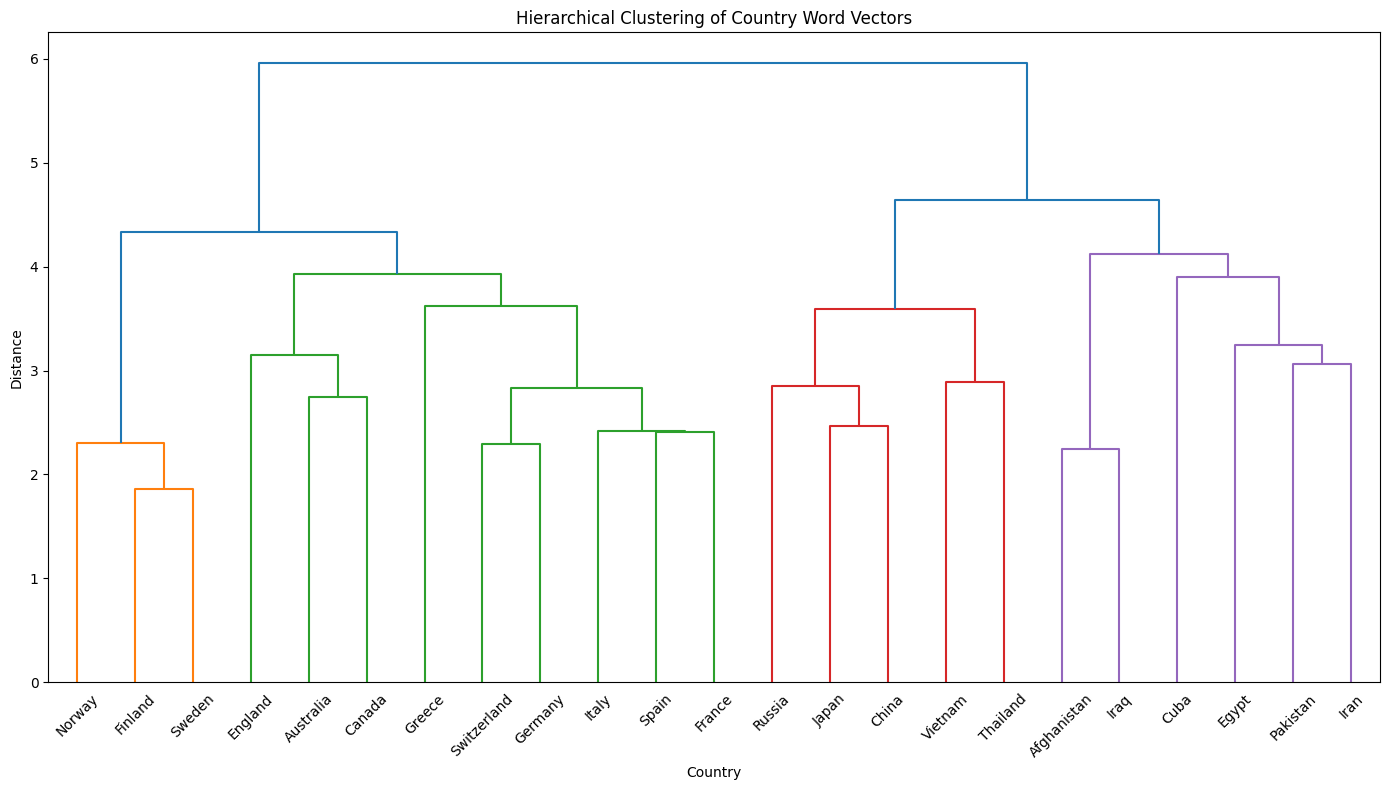


クラスタ 1
Norway
Finland
Sweden

クラスタ 2
England
Greece
Australia
Switzerland
Spain
Canada
Germany
Italy
France

クラスタ 3
Japan
China
Russia
Vietnam
Thailand

クラスタ 4
Afghanistan
Iraq

クラスタ 5
Egypt
Pakistan
Iran
Cuba


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

countries = set()

with open("questions-words.txt", encoding="utf-8") as f:
    use_section = False

    for line in f:
        line = line.strip()

        if line == ": capital-common-countries":
            use_section = True
            continue

        if use_section and line.startswith(":"):
            break

        if use_section:
            words = line.split()

            # [首都 国 首都 国]
            countries.add(words[1])
            countries.add(words[3])

country_names = []
country_vectors = []

for country in countries:
    if country in wv.key_to_index:
        country_names.append(country)
        country_vectors.append(wv[country])

country_vectors = np.array(country_vectors)

# Ward法による階層型クラスタリング
Z = linkage(country_vectors, method="ward")

# デンドログラムの描画
plt.figure(figsize=(14, 8))
dendrogram(
    Z,
    labels=country_names
)

plt.title("Hierarchical Clustering of Country Word Vectors")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

#5クラスタに分ける場合
labels = fcluster(Z, t=5, criterion="maxclust")

for i in range(1, 6):
    print(f"\nクラスタ {i}")
    for country, label in zip(country_names, labels):
        if label == i:
            print(country)

## 59. t-SNEによる可視化

ベクトル空間上の国名に関する単語ベクトルをt-SNEで可視化せよ。

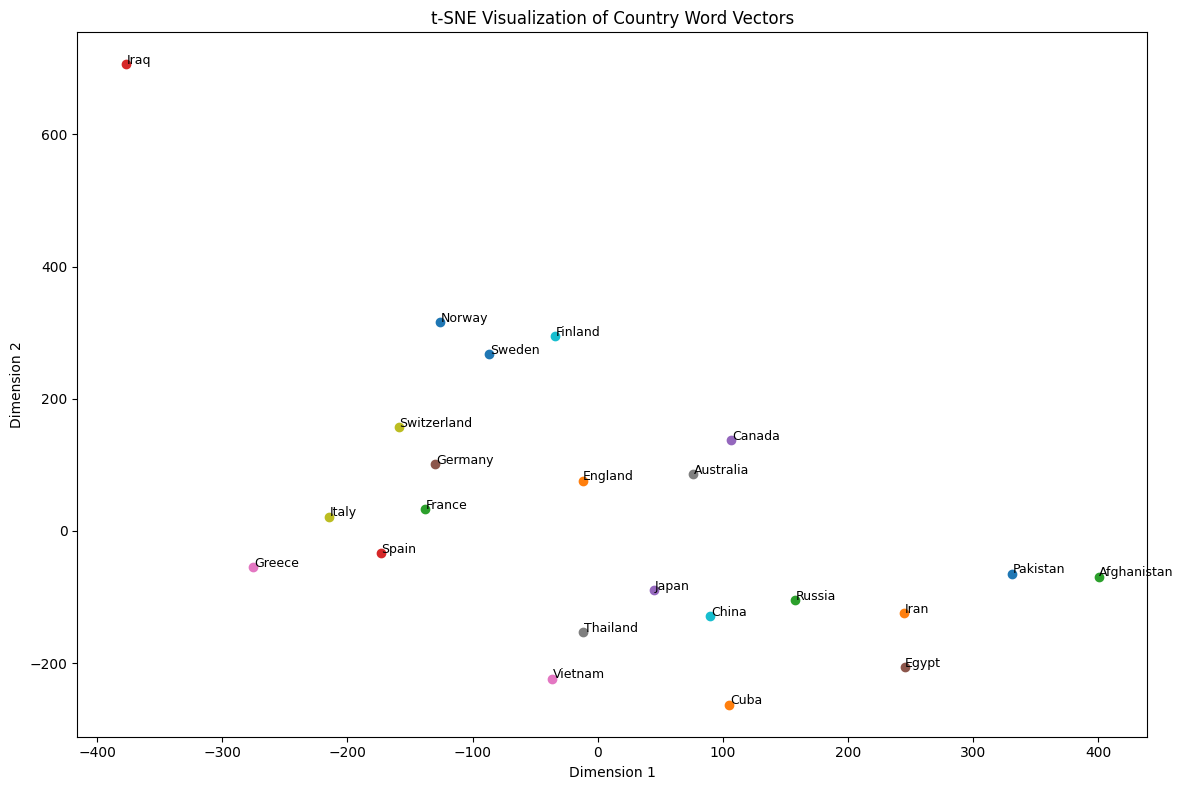

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

countries = set()

with open("questions-words.txt", encoding="utf-8") as f:
    use_section = False

    for line in f:
        line = line.strip()

        if line == ": capital-common-countries":
            use_section = True
            continue

        if use_section and line.startswith(":"):
            break

        if use_section:
            words = line.split()

            # [首都 国 首都 国]
            countries.add(words[1])
            countries.add(words[3])

country_names = []
country_vectors = []

for country in countries:
    if country in wv.key_to_index:
        country_names.append(country)
        country_vectors.append(wv[country])

country_vectors = np.array(country_vectors)

# t-SNE により 2次元へ圧縮
tsne = TSNE(
    n_components=2,
    random_state=0,
    perplexity=5
)

reduced_vectors = tsne.fit_transform(country_vectors)

# 可視化
plt.figure(figsize=(12, 8))

for i, country in enumerate(country_names):
    x = reduced_vectors[i, 0]
    y = reduced_vectors[i, 1]

    plt.scatter(x, y)
    plt.text(x + 0.5, y + 0.5, country, fontsize=9)

plt.title("t-SNE Visualization of Country Word Vectors")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.show()